# Analysis of number of cells per pseudobulk in train and test data

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
import math
warnings.filterwarnings('ignore')
import joblib
import matplotlib.colors as mcolors
from pathlib import Path

### Load data into list of dataframes

In [2]:
base_dir = Path("../../runs_for_grood_paper/complete_set_of_runs/revisions/grood_no_cells_per_pseudobulk/")
dataframes = []

for file in base_dir.glob('*/inference/MasterTable.csv'):
    variable_name = file.parent.parent.name

    df = pred = pd.read_csv(file, index_col=0)
    df['setting'] = variable_name
    df.index = df['SampleID']
    df.drop(['SampleID', 'error'], axis=1, inplace=True)

    dataframes.append(df)

combined_df = pd.concat(dataframes, axis=0, ignore_index=True)
combined_df

,B cells,CD4 T cells,CD8 T cells,DC,Monocytes,NK cells,Tregs,Pred B cells,Pred CD4 T cells,Pred CD8 T cells,Pred DC,Pred Monocytes,Pred NK cells,Pred Tregs,setting
0,0.116735,0.454836,0.013104,0.230469,0.000000,0.165550,0.019306,0.119939,0.431042,0.016673,0.231742,0.003829,0.161165,0.019690,500_10000
1,0.003101,0.000000,0.028909,0.120036,0.517155,0.304091,0.026708,0.005613,0.006343,0.022936,0.121257,0.520580,0.302404,0.020867,500_10000
2,0.150630,0.165733,0.023705,0.000000,0.373775,0.274655,0.011502,0.152294,0.152877,0.020796,0.002832,0.374723,0.283189,0.013289,500_10000
3,0.420326,0.000000,0.017005,0.023407,0.237871,0.285586,0.015805,0.413063,0.003145,0.017314,0.023615,0.233058,0.290901,0.018905,500_10000
4,0.049410,0.812362,0.002100,0.025705,0.000000,0.082717,0.027706,0.059063,0.691527,0.008999,0.029276,0.005268,0.088841,0.033402,500_10000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4895,0.029087,0.204614,0.339017,0.068205,0.065196,0.041123,0.252758,0.036272,0.215126,0.360059,0.059776,0.069859,0.039824,0.219085,10000_1000
4896,0.028056,0.090180,0.168337,0.016032,0.200401,0.370741,0.126253,0.024671,0.087648,0.187298,0.019616,0.188475,0.360712,0.131580,10000_1000
4897,0.213641,0.288867,0.064193,0.077232,0.037111,0.250752,0.068205,0.206874,0.258873,0.100801,0.081675,0.036171,0.244177,0.071428,10000_1000
4898,0.015045,0.209629,0.001003,0.048144,0.284855,0.223671,0.217653,0.015974,0.156134,0.004750,0.053130,0.311431,0.198224,0.188368,10000_1000


In [3]:
# Correlation analysis

def getCorr(df, cellTypes):

    """
    Computes correlation and error metrics for predicitions vs. ground-truth as stored in the MasterTable
    df: MasterTable of samples x cell types (predicted proportions with prefix 'Pred ', groundtruth only with cell type name)
    cellTypes: basically list of cell types as in groundtruth
    """

    ground_truth_cols = [x for x in cellTypes]
    ground_truth_cols.append('setting')
    pred_cols = [f"Pred {x}" for x in cellTypes]
    pred_cols.append('setting')

    rsquared = []
    cccs = []
    rmses = []
    spearmans = []
    percent_dev = []
    absol_dev = []

    # Concordance correlation coefficient
    def ccc(x_data,y_data):
        sxy = np.sum((x_data - np.mean(x_data))*(y_data - np.mean(y_data)))/len(x_data)
        rhoc = 2*sxy / (np.var(x_data) + np.var(y_data) + (np.mean(x_data) - np.mean(y_data))**2)
        return rhoc


    # Pearson Correlation Coefficient
    def r(x_data,y_data):
        ''' Pearson Correlation Coefficient'''
        sxy = np.sum((x_data - np.mean(x_data))*(y_data - np.mean(y_data)))/len(x_data)
        rho = sxy / (np.std(x_data)*np.std(y_data))
        return rho


    # RMSE
    def rmse(x_data,y_data):
        MSE = np.mean(np.square((np.array(x_data)-np.array(y_data))))
        RMSE = np.sqrt(MSE)
        return RMSE

    # Spearmans rank correlation    
    def spearman(x_data, y_data):
        spearmanCorr, _ = stats.spearmanr(np.array(x_data), np.array(y_data))
        return spearmanCorr
    
    # Percent deviation function
    def frac_deviation(x_data, y_data):
        frac_devs = np.mean(np.divide((np.array(y_data) - np.array(x_data)),np.array(x_data), where=(np.array(x_data)!=0)))
        return frac_devs # for sparse data, quite some data points might be excluded due to the removal of 0-divisions from the mean
    
    # Absolute deviation function
    def abs_deviation(x_data, y_data):
        abs_devs = np.mean(abs(np.array(y_data) - np.array(x_data)))
        return abs_devs

    pred = df[pred_cols]
    gt = df[ground_truth_cols]
    settings = []

    for sample in df.index.tolist():
        
        xdata = gt.loc[sample]
        xdata.drop(labels=['setting'], inplace=True)
        xdata = xdata.to_list()
        ydata = pred.loc[sample]
        ydata.drop('setting', inplace=True)
        ydata = ydata.to_list()
        b = r(xdata, ydata)
        rsquared.append(b)
        c = ccc(xdata, ydata)
        cccs.append(c)
        a = rmse(xdata, ydata)
        rmses.append(a)
        g = abs_deviation(xdata, ydata)
        absol_dev.append(g)
        settings.append(gt.loc[sample,'setting'])


        #print('R: ', str(b), ' for ', cell)
        #print('CCC: ', str(c), ' for ', cell)
        #print('SpearmanR: ', str(s), ' for ', cell)
        #print('RMSE: ', str(a), ' for ', cell)
        #print('Mean percent deviation: ', str(f), ' for ', cell)
        #print('Mean absolute deviation: ', str(g), ' for ', cell)

    DF = pd.concat([pd.Series(rsquared), pd.Series(cccs), pd.Series(rmses), pd.Series(absol_dev), pd.Series(settings)], axis = 1, ignore_index = True)
    DF.columns = ['PCC', 'CCC', 'RMSE', 'MAD', 'Setting']
    DF.index = df.index

    return DF

corr_res = getCorr(combined_df, ['B cells', 'CD4 T cells',	'CD8 T cells', 'DC', 'Monocytes', 'NK cells', 'Tregs'])
corr_res

,PCC,CCC,RMSE,MAD,Setting
0,0.999551,0.997924,0.009448,0.005777,500_10000
1,0.999729,0.999717,0.004349,0.003857,500_10000
2,0.998972,0.998946,0.006112,0.004504,500_10000
3,0.999749,0.999637,0.004206,0.003451,500_10000
4,0.999765,0.983507,0.046063,0.022578,500_10000
...,...,...,...,...,...
4895,0.990058,0.989910,0.016183,0.012401,10000_1000
4896,0.996475,0.996156,0.009721,0.007964,10000_1000
4897,0.988384,0.979487,0.018361,0.012650,10000_1000
4898,0.973083,0.967869,0.027026,0.020638,10000_1000


In [4]:
df_plot = corr_res.groupby('Setting').mean()
df_plot['Setting'] = df_plot.index.tolist()

In [5]:
df_plot['no_cells_train'] = df_plot['Setting'].str.split('_', expand=True)[0]
df_plot['no_cells_test'] = df_plot['Setting'].str.split('_', expand=True)[1]
df_plot['no_cells_train'] = pd.to_numeric(df_plot['no_cells_train'])
# df_plot['no_cells_test'] = pd.to_numeric(df_plot['no_cells_test'])
df_plot

,PCC,CCC,RMSE,MAD,Setting,no_cells_train,no_cells_test
Setting,,,,,,,
10000_100,0.948364,0.925925,0.043609,0.032509,10000_100,10000,100
10000_1000,0.990476,0.987229,0.019048,0.013306,10000_1000,10000,1000
10000_10000,0.997340,0.995635,0.010996,0.007761,10000_10000,10000,10000
10000_200,0.967098,0.951890,0.035075,0.024388,10000_200,10000,200
10000_2000,0.994254,0.991145,0.015298,0.010576,10000_2000,10000,2000
10000_500,0.983317,0.977717,0.022855,0.016545,10000_500,10000,500
10000_5000,0.997038,0.995491,0.011039,0.007765,10000_5000,10000,5000
1000_100,0.976438,0.967799,0.029315,0.021341,1000_100,1000,100
1000_1000,0.995303,0.993538,0.013187,0.009450,1000_1000,1000,1000


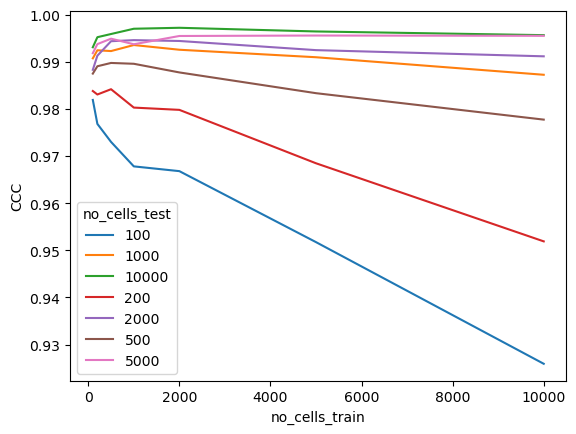

In [10]:
ax = sns.lineplot(df_plot, x='no_cells_train', y='CCC', hue='no_cells_test')
plt.savefig('No_cells_pseudobulk_train_vs_test.svg', dpi=300)
plt.show()